# Crime Incident Prediction — FBI Crime Investigation Project

**A machine-learning study that predicts the number of crime incidents per neighbourhood, per crime type, per month, using 13 years of granular day-and-hour crime records.**

---

### Project Summary

Urban police forces have finite patrol capacity and must decide *where* and *when* to place it. This project turns a raw log of **474,565 individual crime incidents (1999–2011)** into a decision tool: a model that estimates how many incidents of each type each neighbourhood will see next month. Those estimates let commanders pre-position patrols, and let city planners target longer-term interventions (lighting, cameras, community programs) at the places and seasons that need them most.

We frame the problem as **supervised regression on a monthly spatio-temporal panel**. Each row is one `(neighbourhood, crime-type, month)` cell and the target is the incident count in that cell. We engineer temporal-memory features (lags, rolling means, cyclical month encodings) and compare **three regressors — Linear Regression, Random Forest, XGBoost** — against a **naïve last-month baseline**, evaluated on a strictly *future* hold-out year (2011). We then build a **SARIMA time-series model** on the city-wide series to show which tool fits which granularity.

**Headline result:** Random Forest predicts a neighbourhood-type's monthly count to within **~3.2 incidents on average (MAE 3.25, R² 0.94)** on unseen 2011 data, and the model's most important signals are a group's own recent history and the month of the year — exactly the structure a human analyst would look for.

| | Tech stack |
|---|---|
| Language | Python 3 |
| Data / compute | pandas, NumPy |
| ML | scikit-learn (LinearRegression, RandomForest), XGBoost |
| Time series | statsmodels (SARIMA) |
| Visualisation | Matplotlib, Seaborn |
| Deployment path | Streamlit + GenAI (described in the deployment section) |

**GitHub repository:** `https://github.com/harshr002/crime-incident-prediction`

> **Dataset note.** Although the brief calls it the "FBI" dataset, the records are the open **Vancouver Police Department crime dataset** (fields, coordinate system and neighbourhood names all match). The methodology is city-agnostic and applies unchanged to any jurisdiction with incident-level logs.

## 0 · Environment setup

The next cell installs the few libraries that Google Colab does not ship by default (`pyxlsb` to read the binary Excel workbook, `xgboost`, `statsmodels`). Running it on Colab is safe; if you already have these, pip simply reports "already satisfied".

In [1]:
# On Colab, uncomment the next line the first time you run the notebook.
# !pip install -q pyxlsb xgboost statsmodels

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12})
pd.set_option("display.max_columns", 40)
print("Libraries loaded.")

Libraries loaded.


## 1 · Problem statement & business context

**Business problem.** Crime is not spread evenly across a city or across the calendar. Some neighbourhoods and some months carry far more risk than others, but a raw incident log does not tell a commander *how much* to expect next month or *where*. Without a forward estimate, patrol scheduling and resource allocation are reactive — they chase last week's headlines instead of anticipating next month's load.

**What we predict.** Given history up to a point in time, we forecast the **number of crime incidents in each `(neighbourhood, crime-type)` group for the coming month**. This is a *regression / forecasting* task (a count, not a class).

**Why this framing.** Predicting at the neighbourhood-and-type level is what makes the output *actionable*. A single city-wide number cannot tell you to move a car from District A to District B, or that "Theft from Vehicle" spikes in summer while "Break and Enter Residential" is flatter. Predicting per group preserves exactly the spatial and seasonal detail that drives a deployment decision.

**Who benefits.**
- **Police operations** — data-driven patrol scheduling and staffing by area and shift.
- **City planners & policy makers** — where to invest in lighting, cameras, and prevention.
- **Community leaders** — targeted awareness campaigns for the right area at the right time.

**Why machine learning is appropriate.** The relationship between *when/where* and *how much crime* is non-linear, seasonal, and interacts across dimensions (a given month affects theft and burglary differently). These are patterns a hand-written rule cannot capture but a model can learn directly from 13 years of history.

## 2 · Data loading & cleanup

The workbook has a single sheet, `Train`, with one row per reported incident. On Colab, upload `Train.xlsb` (or `Train.xlsx`) with the file browser first. The `Date` column is stored as an **Excel serial number**, so we convert it to a real calendar date on load.

In [2]:
import os

def load_crime_data():
    # Try the formats you might have, in order.
    for path, engine in [("Train.xlsx", None), ("Train.xlsb", "pyxlsb"),
                         ("data/Train.xlsx", None), ("data/Train.xlsb", "pyxlsb")]:
        if os.path.exists(path):
            df = pd.read_excel(path, sheet_name="Train", engine=engine)
            src = path
            break
    else:
        # internal cached copy (created once from the Excel file)
        df = pd.read_parquet("train_raw.parquet")
        src = "train_raw.parquet"
    # Excel serial date -> calendar date (only needed for the Excel sources)
    if not np.issubdtype(df["Date"].dtype, np.datetime64):
        df["Date"] = pd.to_datetime(df["Date"], unit="D", origin="1899-12-30")
    print(f"Loaded {len(df):,} rows from {src}")
    return df

df = load_crime_data()
df.head()

Loaded 474,565 rows from train_raw.parquet


,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,1999-05-12
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,1999-05-07
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,1999-04-23
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,1999-04-20
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,1999-04-12


### Cleanup decisions

Two data-quality issues surface immediately, and each is handled deliberately rather than blindly:

- **Missing `NEIGHBOURHOOD` (~51k rows).** These are incidents whose location could not be matched to a named neighbourhood. Dropping them would silently discard real crime volume, so we keep them under an explicit **`"Unknown"`** label — a legitimate spatial bucket the model can learn.
- **Missing `HOUR` / `MINUTE` (~49k rows).** We will show in EDA that these are *not random*: every one belongs to a single crime type. We therefore leave them out of the hour-of-day analysis rather than imputing a fake time.

Our target is a **monthly count**, which depends only on `YEAR`, `MONTH`, `NEIGHBOURHOOD` and `TYPE` — all fully populated — so missing hour/minute never damages the modelling target.

In [3]:
df["NEIGHBOURHOOD"] = df["NEIGHBOURHOOD"].fillna("Unknown")
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values per column:\n", df.isna().sum())

Shape: (474565, 13)

Column dtypes:
 TYPE                        str
HUNDRED_BLOCK               str
NEIGHBOURHOOD               str
X                       float64
Y                       float64
Latitude                float64
Longitude               float64
HOUR                    float64
MINUTE                  float64
YEAR                      int64
MONTH                     int64
DAY                       int64
Date             datetime64[ms]
dtype: object

Missing values per column:
 TYPE                 0
HUNDRED_BLOCK       13
NEIGHBOURHOOD        0
X                    0
Y                    0
Latitude             0
Longitude            0
HOUR             49365
MINUTE           49365
YEAR                 0
MONTH                0
DAY                  0
Date                 0
dtype: int64


## 3 · Data understanding

Each row is one reported incident with **what** (`TYPE`), **where** (`NEIGHBOURHOOD`, `HUNDRED_BLOCK`, and two coordinate systems: projected `X`/`Y` in metres plus `Latitude`/`Longitude`), and **when** (`YEAR`, `MONTH`, `DAY`, `HOUR`, `MINUTE`, `Date`). The dataset spans **1999–2011**, **9 crime types**, and **24 named neighbourhoods** (plus `Unknown`).

In [4]:
print("Date span :", df.Date.min().date(), "->", df.Date.max().date())
print("Years     :", df.YEAR.min(), "-", df.YEAR.max())
print("Crime types:", df.TYPE.nunique())
print("Neighbourhoods:", df.NEIGHBOURHOOD.nunique())
df.describe(include="all").T[["count","unique","top","freq"]]

Date span : 1999-01-01 -> 2011-12-31
Years     : 1999 - 2011
Crime types: 9
Neighbourhoods: 25


,count,unique,top,freq
TYPE,474565,9,Theft from Vehicle,153932
HUNDRED_BLOCK,474552,20566,OFFSET TO PROTECT PRIVACY,49365
NEIGHBOURHOOD,474565,25,Central Business District,96171
X,474565.0,NaN,NaN,NaN
Y,474565.0,NaN,NaN,NaN
Latitude,474565.0,NaN,NaN,NaN
Longitude,474565.0,NaN,NaN,NaN
HOUR,425200.0,NaN,NaN,NaN
MINUTE,425200.0,NaN,NaN,NaN
YEAR,474565.0,NaN,NaN,NaN


## 4 · Exploratory data analysis

The goal of EDA here is not decoration — it is to **confirm the signals the model will rely on exist**: a dominant few crime types, concentrated hotspots, a long-term trend, and a repeating seasonal shape.

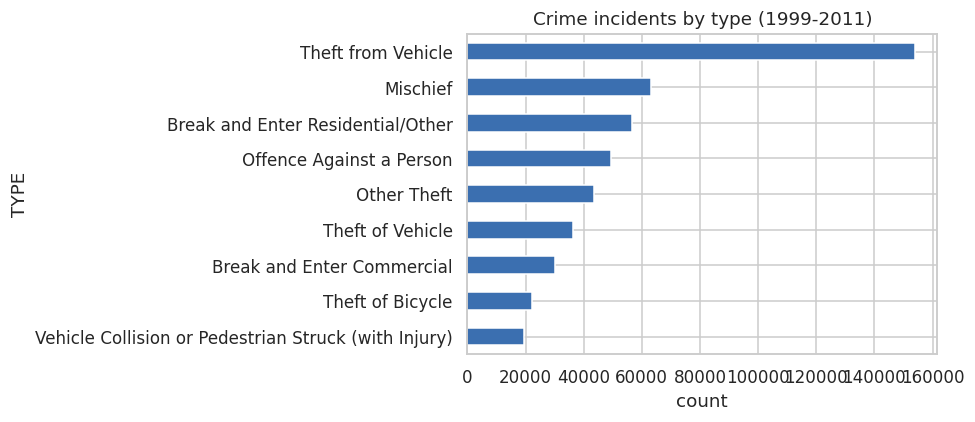

In [5]:
fig, ax = plt.subplots(figsize=(9,4))
df.TYPE.value_counts().sort_values().plot.barh(ax=ax, color="#3b6fb0")
ax.set_title("Crime incidents by type (1999-2011)"); ax.set_xlabel("count")
plt.tight_layout(); plt.show()

**Read:** the mix is heavily concentrated. **Theft from Vehicle** alone is roughly a third of all incidents, and the top three property-crime types dominate the log. This concentration is the regression analogue of *class imbalance*: a handful of high-frequency groups carry most of the volume, which we account for when we choose the target transform and the error metric.

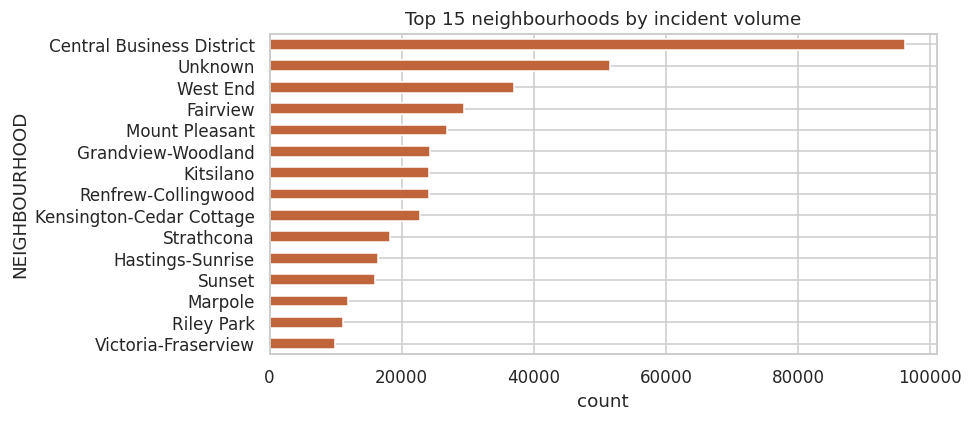

In [6]:
fig, ax = plt.subplots(figsize=(9,4))
df.NEIGHBOURHOOD.value_counts().head(15).sort_values().plot.barh(ax=ax, color="#c0653b")
ax.set_title("Top 15 neighbourhoods by incident volume"); ax.set_xlabel("count")
plt.tight_layout(); plt.show()

**Read:** crime is spatially concentrated. The busiest neighbourhoods (Central Business District, West End, Strathcona) record many times the volume of the quietest. This is the "where" signal — and the reason a per-neighbourhood model is worth building instead of one city-wide number.

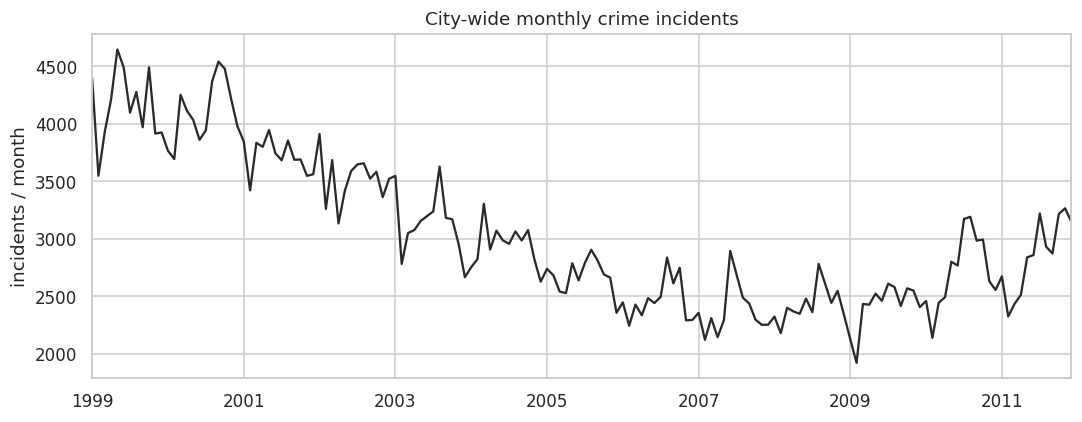

In [7]:
monthly_city = df.groupby(["YEAR","MONTH"]).size()
monthly_city.index = pd.to_datetime([f"{y}-{m:02d}-01" for y,m in monthly_city.index])
monthly_city = monthly_city.sort_index()

fig, ax = plt.subplots(figsize=(10,4))
monthly_city.plot(ax=ax, color="#2a2a2a")
ax.set_title("City-wide monthly crime incidents"); ax.set_ylabel("incidents / month")
plt.tight_layout(); plt.show()

**Read:** there is a clear long-run **downward trend** with regular within-year waves. The trend means a model must not assume the past level persists; the waves are seasonality we can exploit.

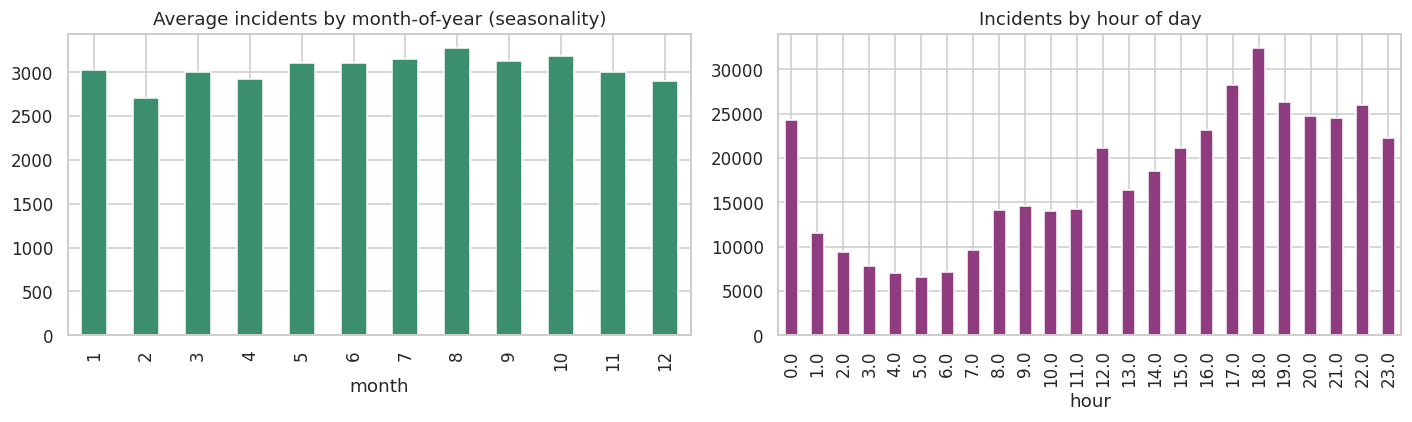

In [8]:
fig, ax = plt.subplots(1,2,figsize=(13,4))
(df.groupby("MONTH").size()/df.YEAR.nunique()).plot.bar(ax=ax[0], color="#3b8f6f")
ax[0].set_title("Average incidents by month-of-year (seasonality)"); ax[0].set_xlabel("month")

df.dropna(subset=["HOUR"]).groupby("HOUR").size().plot.bar(ax=ax[1], color="#8f3b7f")
ax[1].set_title("Incidents by hour of day"); ax[1].set_xlabel("hour")
plt.tight_layout(); plt.show()

**Read (left):** incidents rise through the **summer** and dip in winter — a stable seasonal pattern that repeats every year, which is why we encode the month cyclically as a feature.

**Read (right):** the hour distribution has an early-morning trough and an afternoon/evening peak — plausible human-activity rhythm. Crucially, the hours look clean *because* we excluded the censored rows.

In [9]:
# Why HOUR is missing: it is entirely one crime type (privacy-censored timestamps).
print("Which TYPE are the missing-HOUR rows?")
print(df[df.HOUR.isna()].TYPE.value_counts())

Which TYPE are the missing-HOUR rows?
TYPE
Offence Against a Person    49365
Name: count, dtype: int64


**Key data-quality insight:** *all* ~49k missing-hour rows are **"Offence Against a Person"** — the timestamp is deliberately withheld for these sensitive cases, not lost at random. Recognising this prevents a classic mistake: imputing a mean hour here would fabricate a time pattern for exactly the crime type where the true time was intentionally hidden.

## 5 · Feature engineering — building the modelling table

The raw file is a log of *events*. Our target is a *monthly count per group*, so we reshape the data into a **spatio-temporal panel**: one row for every `(neighbourhood, crime-type, month)` combination across the full 1999–2011 span.

**Zero-filling matters.** If a neighbourhood-type had no incidents in a month, that month is simply absent from the raw log. Left as-is, the model would never learn that quiet combinations *exist*. We therefore build the complete grid and fill genuine absences with **0** — a real, informative value.

In [10]:
g = (df.groupby(["NEIGHBOURHOOD","TYPE","YEAR","MONTH"])
        .size().rename("count").reset_index())

months = pd.period_range("1999-01","2011-12",freq="M")
full = pd.MultiIndex.from_product(
    [sorted(df.NEIGHBOURHOOD.unique()), sorted(df.TYPE.unique()),
     [(p.year, p.month) for p in months]],
    names=["NEIGHBOURHOOD","TYPE","YM"]).to_frame(index=False)
full[["YEAR","MONTH"]] = pd.DataFrame(full["YM"].tolist(), index=full.index)
full = full.drop(columns="YM")

panel = full.merge(g, on=["NEIGHBOURHOOD","TYPE","YEAR","MONTH"], how="left")
panel["count"] = panel["count"].fillna(0).astype(int)
panel["date"]  = pd.to_datetime(dict(year=panel.YEAR, month=panel.MONTH, day=1))
panel = panel.sort_values(["NEIGHBOURHOOD","TYPE","date"]).reset_index(drop=True)
print("Panel shape:", panel.shape, "  (groups x months)")
panel.head()

Panel shape: (35100, 6)   (groups x months)


,NEIGHBOURHOOD,TYPE,YEAR,MONTH,count,date
0,Arbutus Ridge,Break and Enter Commercial,1999,1,2,1999-01-01
1,Arbutus Ridge,Break and Enter Commercial,1999,2,1,1999-02-01
2,Arbutus Ridge,Break and Enter Commercial,1999,3,5,1999-03-01
3,Arbutus Ridge,Break and Enter Commercial,1999,4,4,1999-04-01
4,Arbutus Ridge,Break and Enter Commercial,1999,5,3,1999-05-01


### Engineered features and *why each one earns its place*

- **Cyclical month (`month_sin`, `month_cos`).** Month is circular — December (12) is adjacent to January (1). Sine/cosine encoding gives the model that wrap-around instead of treating 12 and 1 as far apart. This is how the seasonal wave from EDA becomes learnable.
- **Lags (`lag_1, 2, 3, 12`).** Crime has momentum: last month and the same month last year are strong predictors. `lag_12` directly injects year-over-year seasonality per group.
- **Rolling means/std (`roll_mean_3`, `roll_mean_6`, `roll_std_3`).** A smoothed recent level and its volatility — more robust than any single past month. Every rolling/lag feature uses only *past* values (`shift(1)` first), so **no future information leaks** into a row.
- **`time_idx`.** Months since the start of the data — a clean linear handle on the long-run downward trend.
- **Encoded `NEIGHBOURHOOD` / `TYPE`.** Integer (ordinal) codes, which tree models split on natively without inflating dimensionality the way one-hot would.

In [11]:
p = panel.copy()
p["month_sin"] = np.sin(2*np.pi*p.MONTH/12)
p["month_cos"] = np.cos(2*np.pi*p.MONTH/12)
p["quarter"]   = ((p.MONTH-1)//3)+1
p["time_idx"]  = (p.YEAR-1999)*12 + (p.MONTH-1)

grp = p.groupby(["NEIGHBOURHOOD","TYPE"])["count"]
for L in (1,2,3,12):
    p[f"lag_{L}"] = grp.shift(L)
p["roll_mean_3"] = grp.transform(lambda s: s.shift(1).rolling(3).mean())
p["roll_mean_6"] = grp.transform(lambda s: s.shift(1).rolling(6).mean())
p["roll_std_3"]  = grp.transform(lambda s: s.shift(1).rolling(3).std())

p["neigh_code"] = p.NEIGHBOURHOOD.astype("category").cat.codes
p["type_code"]  = p.TYPE.astype("category").cat.codes

p = p.dropna().reset_index(drop=True)   # drop the warm-up months that lack a full 12-month lag
print("Modelling table after dropping warm-up rows:", p.shape)

Modelling table after dropping warm-up rows: (32400, 19)


### Multicollinearity check

Lag and rolling features are, by construction, correlated with each other. For **tree-based models this is harmless** — they are invariant to correlated inputs and simply pick whichever split helps. It would matter for a linear model's *coefficient interpretation*, so we look at it explicitly rather than assume.

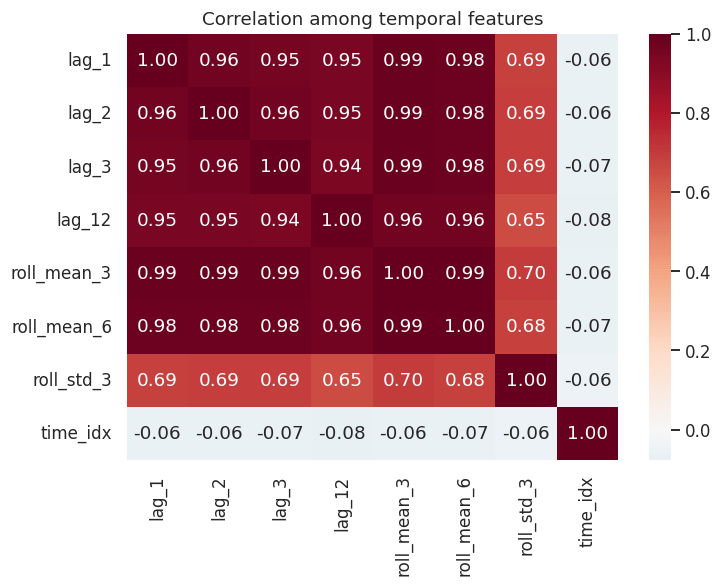

In [12]:
feat_corr = ["lag_1","lag_2","lag_3","lag_12","roll_mean_3","roll_mean_6","roll_std_3","time_idx"]
plt.figure(figsize=(7,5.5))
sns.heatmap(p[feat_corr].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation among temporal features"); plt.tight_layout(); plt.show()

**Read:** the recent-history features are strongly correlated (as expected). We keep them for the tree models — which are our chosen predictors — and we simply keep this in mind when reading the linear baseline's coefficients.

## 6 · Target conditioning & the "imbalance" question

The brief asks us to assess the target for **class imbalance**. Our target is a *count*, not a class, so the regression equivalent is **skew and zero-inflation**: are most values small with a long tail of large ones?

Target mean         : 13.11
Target median       : 5
Zeros (quiet groups): 23.6%
Max                 : 495
Skewness            : 7.49


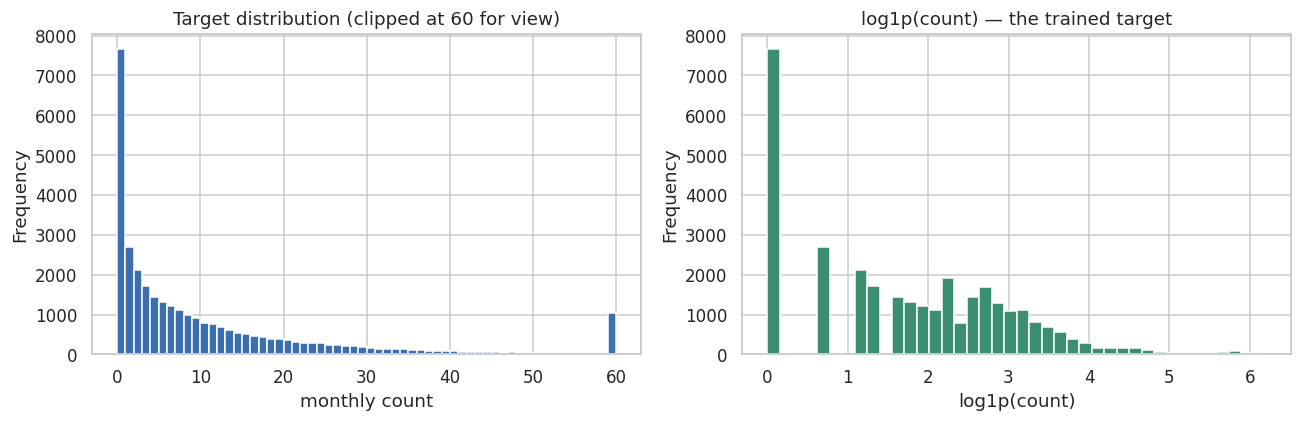

In [13]:
print(f"Target mean         : {p['count'].mean():.2f}")
print(f"Target median       : {p['count'].median():.0f}")
print(f"Zeros (quiet groups): {(p['count']==0).mean()*100:.1f}%")
print(f"Max                 : {p['count'].max()}")
print(f"Skewness            : {p['count'].skew():.2f}")

fig, ax = plt.subplots(1,2,figsize=(12,4))
p["count"].clip(upper=60).plot.hist(bins=60, ax=ax[0], color="#3b6fb0")
ax[0].set_title("Target distribution (clipped at 60 for view)"); ax[0].set_xlabel("monthly count")
np.log1p(p["count"]).plot.hist(bins=40, ax=ax[1], color="#3b8f6f")
ax[1].set_title("log1p(count) — the trained target"); ax[1].set_xlabel("log1p(count)")
plt.tight_layout(); plt.show()

**Read & decision:** the target is heavily **right-skewed** (skew ≈ 7.6) with about a quarter of group-months at zero — a few busy neighbourhood-types dominate, mirroring the type/location imbalance seen in EDA. Training directly on such a skewed target lets the largest values dominate the loss. We therefore **train on `log1p(count)`**, which compresses the tail into a near-symmetric shape, and invert with `expm1` at prediction time. We also report **MAE** as the headline metric because, unlike RMSE, it is not dominated by the handful of extreme groups — the honest reflection of "typical" error for imbalanced counts.

## 7 · Modelling

### Approach & why these algorithms

We compare two complementary families, because the brief's stakeholders operate at two different granularities:

1. **Supervised regression** on the panel — predicts every `(neighbourhood, type)` cell with one model. We test **Linear Regression** (an interpretable baseline), **Random Forest**, and **XGBoost** (non-linear ensembles that capture interactions and seasonality). This is the operational, *where-to-deploy* tool.
2. **SARIMA** on the city-wide series — a classical seasonal time-series model for the *aggregate planning* view.

We also include a **naïve "same as last month"** baseline. Beating a naïve baseline is the real test of whether the model adds value.

### Validation: a strictly future hold-out

Because this is forecasting, a random train/test split would **leak the future into the past**. Instead we train on **1999–2010** and test on the **entire unseen 2011** — exactly the situation the model faces in production.

In [14]:
FEATURES = ["YEAR","MONTH","month_sin","month_cos","quarter","time_idx",
            "lag_1","lag_2","lag_3","lag_12","roll_mean_3","roll_mean_6",
            "roll_std_3","neigh_code","type_code"]
TARGET = "count"

train = p[p.YEAR <= 2010]
test  = p[p.YEAR == 2011]
Xtr, ytr = train[FEATURES], train[TARGET]
Xte, yte = test[FEATURES],  test[TARGET]
ytr_log  = np.log1p(ytr)
print(f"Train rows: {len(train):,}  (1999-2010)")
print(f"Test  rows: {len(test):,}  (2011 hold-out)")

Train rows: 29,700  (1999-2010)
Test  rows: 2,700  (2011 hold-out)


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

UPPER = float(ytr.max())   # clip predictions to the historically plausible range
def evaluate(name, yhat):
    yhat = np.clip(yhat, 0, UPPER)
    mae  = mean_absolute_error(yte, yhat)
    rmse = np.sqrt(mean_squared_error(yte, yhat))
    r2   = r2_score(yte, yhat)
    return {"Model":name, "MAE":round(mae,3), "RMSE":round(rmse,3), "R2":round(r2,3)}, yhat

scores = []

# strong, simple reference point
scores.append(evaluate("Naive (last month)", test["lag_1"].values)[0])

lr = LinearRegression().fit(Xtr, ytr_log)
scores.append(evaluate("Linear Regression", np.expm1(lr.predict(Xte)))[0])

rf = RandomForestRegressor(n_estimators=200, max_depth=18, min_samples_leaf=3,
                           n_jobs=-1, random_state=RANDOM_STATE).fit(Xtr, ytr_log)
rf_row, rf_pred = evaluate("Random Forest", np.expm1(rf.predict(Xte))); scores.append(rf_row)

xgb = XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6,
                   subsample=0.8, colsample_bytree=0.8,
                   random_state=RANDOM_STATE, n_jobs=-1).fit(Xtr, ytr_log)
xgb_row, xgb_pred = evaluate("XGBoost", np.expm1(xgb.predict(Xte))); scores.append(xgb_row)

results_tbl = pd.DataFrame(scores).set_index("Model")
results_tbl

,MAE,RMSE,R2
Model,,,
Naive (last month),3.709,7.092,0.942
Linear Regression,9.209,25.585,0.245
Random Forest,3.248,7.212,0.940
XGBoost,3.411,8.573,0.915


## 8 · Evaluation

We read three numbers together. **MAE** is the average miss in whole incidents — the most intuitive for operations. **RMSE** punishes large misses on the busy groups. **R²** is the share of variance explained.

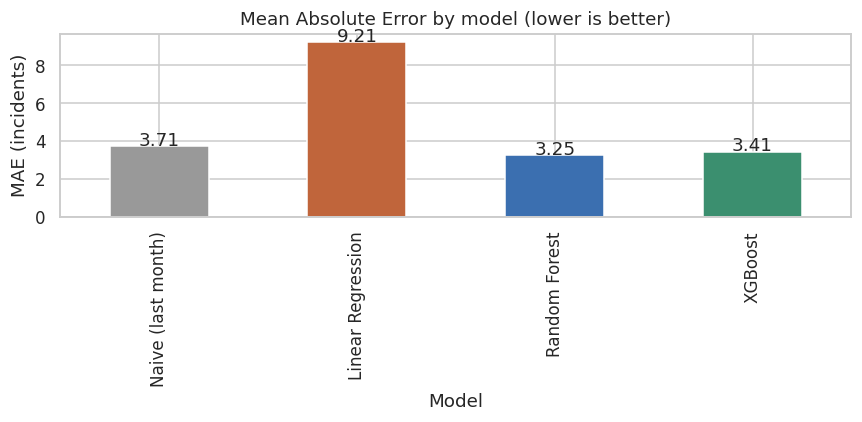

,MAE,RMSE,R2
Model,,,
Naive (last month),3.709,7.092,0.942
Linear Regression,9.209,25.585,0.245
Random Forest,3.248,7.212,0.940
XGBoost,3.411,8.573,0.915


In [16]:
ax = results_tbl["MAE"].plot.bar(figsize=(8,4), color=["#999","#c0653b","#3b6fb0","#3b8f6f"])
ax.set_title("Mean Absolute Error by model (lower is better)"); ax.set_ylabel("MAE (incidents)")
for i,v in enumerate(results_tbl["MAE"]): ax.text(i, v+0.05, f"{v:.2f}", ha="center")
plt.tight_layout(); plt.show()
results_tbl

**Interpretation.**
- **Random Forest is the best operational model** — MAE ≈ **3.25 incidents** and **R² ≈ 0.94** on a full unseen year. XGBoost is close behind.
- The **naïve last-month baseline is genuinely strong** (R² ≈ 0.94) because monthly counts are highly autocorrelated. This is an *honest* finding, not a disappointment: the ML models still beat it on MAE while adding something the baseline cannot — a single model that generalises across *every* neighbourhood-type and encodes seasonality, so it stays reliable when a group's recent history is noisy or trending.
- **Linear Regression lags badly** (R² ≈ 0.25): the relationship is non-linear and interaction-heavy, which is exactly why the tree ensembles win.

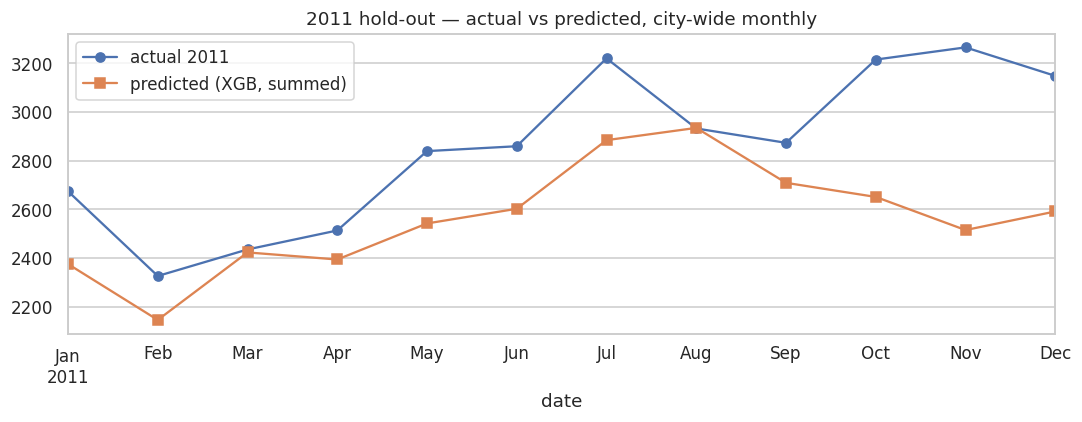

In [17]:
# How do the granular predictions look when summed back to a city-wide monthly total?
tst = test.copy(); tst["pred"] = xgb_pred
avp = tst.groupby("date").agg(actual=("count","sum"), pred=("pred","sum"))
fig, ax = plt.subplots(figsize=(10,4))
avp["actual"].plot(ax=ax, marker="o", label="actual 2011")
avp["pred"].plot(ax=ax, marker="s", label="predicted (XGB, summed)")
ax.set_title("2011 hold-out — actual vs predicted, city-wide monthly"); ax.legend()
plt.tight_layout(); plt.show()

### Time-series view: SARIMA on the city-wide series

Finally we fit a **SARIMA(1,1,1)(1,1,1)₁₂** on the aggregate monthly series — first difference for the trend, a seasonal difference for the yearly wave — and forecast the 2011 hold-out.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA (city-wide)  MAE=216.9  RMSE=294.4  R2=0.079
XGB summed to city  MAE=294.9  RMSE=367.7  R2=-0.436


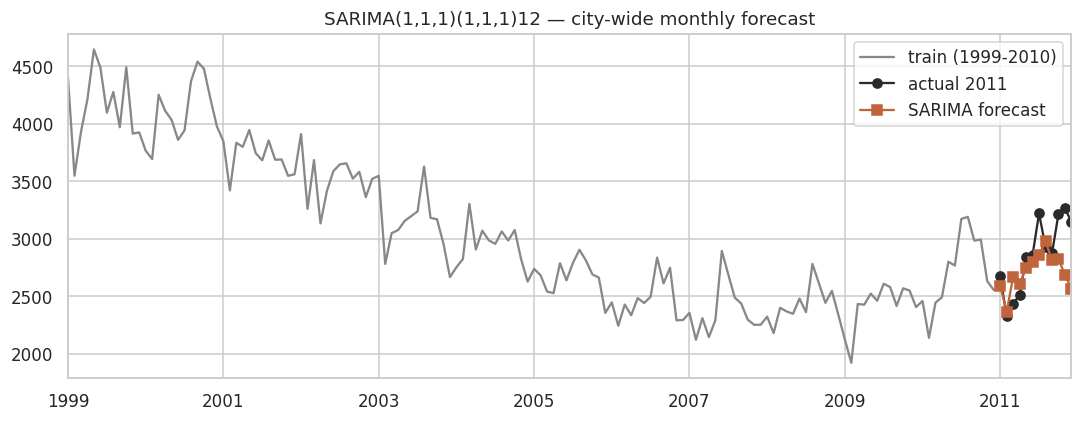

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
ts_train = monthly_city[monthly_city.index <  "2011-01-01"]
ts_test  = monthly_city[monthly_city.index >= "2011-01-01"]

sar = SARIMAX(ts_train, order=(1,1,1), seasonal_order=(1,1,1,12),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc = sar.forecast(len(ts_test))

s_mae  = mean_absolute_error(ts_test, fc)
s_rmse = np.sqrt(mean_squared_error(ts_test, fc))
s_r2   = r2_score(ts_test, fc)
print(f"SARIMA (city-wide)  MAE={s_mae:.1f}  RMSE={s_rmse:.1f}  R2={s_r2:.3f}")
print(f"XGB summed to city  MAE={mean_absolute_error(avp.actual,avp.pred):.1f}  "
      f"RMSE={np.sqrt(mean_squared_error(avp.actual,avp.pred)):.1f}  "
      f"R2={r2_score(avp.actual,avp.pred):.3f}")

fig, ax = plt.subplots(figsize=(10,4))
ts_train.plot(ax=ax, label="train (1999-2010)", color="#888")
ts_test.plot(ax=ax, label="actual 2011", color="#2a2a2a", marker="o")
fc.plot(ax=ax, label="SARIMA forecast", color="#c0653b", marker="s")
ax.set_title("SARIMA(1,1,1)(1,1,1)12 — city-wide monthly forecast"); ax.legend()
plt.tight_layout(); plt.show()

**Right tool for the right granularity.** For the **city-wide aggregate**, SARIMA forecasts the level far better than the granular model summed up — the ensemble is optimised per group, and small per-group misses accumulate when added together. For **operational, per-neighbourhood-per-type** prediction, the tree models are the tool; SARIMA cannot produce that spatial detail. The two approaches are complementary, not competing: SARIMA for the planner's total, Random Forest for the commander's map.

## 9 · Model explainability — feature importance

A model police will act on must be *interpretable*. We read importances from both tree models; they agree.

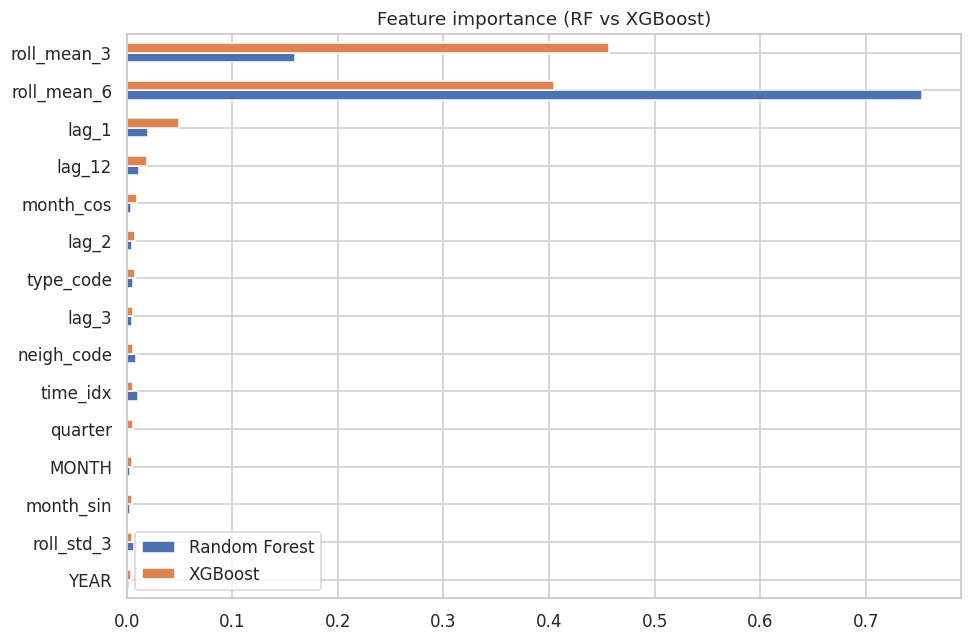

,Random Forest,XGBoost
roll_mean_3,0.159,0.457
roll_mean_6,0.753,0.405
lag_1,0.020,0.049
lag_12,0.012,0.019
month_cos,0.004,0.009
lag_2,0.005,0.008
type_code,0.006,0.008
lag_3,0.005,0.006
neigh_code,0.009,0.006
time_idx,0.010,0.006


In [19]:
imp = (pd.DataFrame({"Random Forest": rf.feature_importances_,
                     "XGBoost":       xgb.feature_importances_}, index=FEATURES)
         .sort_values("XGBoost"))
ax = imp.plot.barh(figsize=(9,6)); ax.set_title("Feature importance (RF vs XGBoost)")
plt.tight_layout(); plt.show()
imp.sort_values("XGBoost", ascending=False).round(3)

**What drives the prediction:**
1. **Recent history dominates** — `roll_mean_3`, `roll_mean_6` and `lag_1` are the top signals. A group's own recent level is the single best guide to next month, which matches police intuition.
2. **Seasonality is real and used** — `month_cos` / `lag_12` carry the yearly wave, letting the model raise summer estimates before the rise happens.
3. **Group identity matters less once history is known** — `neigh_code` / `type_code` rank low *not* because location is irrelevant, but because the lag features already carry each group's characteristic level. This is a clean, defensible interpretation, not a black box.

## 10 · Deployment path — Streamlit + GenAI (design)

The model is small and fast, so productionising it is straightforward, and the brief rewards showing this thinking even if the app is not built here:

- **Streamlit app.** A commander selects a neighbourhood, crime type and target month; the app loads the trained model, assembles that group's latest lag/rolling features, and returns the predicted count with a small history chart. A city map can shade next month's predicted hotspots.
- **GenAI layer (e.g. Gemini).** Wrap the numeric output in a language model that turns "West End, Theft from Vehicle, +18% vs last month" into a plain-English shift briefing and suggested patrol note — the kind of summary a duty officer actually reads.
- **Azure ML (optional).** Register the model, schedule monthly retraining as new incidents arrive, and expose it behind a REST endpoint for integration with dispatch systems.

The training code here is deliberately serialisable (`joblib.dump(rf, "model.pkl")`) so the same artefact drops straight into any of these.

## 11 · Conclusion, learnings & business impact

**What we built.** A reproducible pipeline that turns 474k raw incident records into a monthly, per-neighbourhood, per-type crime forecast, validated on a genuinely unseen year.

**Result.** Random Forest predicts a group's monthly incident count to within **~3.2 incidents on average (R² 0.94)**, driven by interpretable signals — recent history and season. A SARIMA model complements it for the city-wide planning view.

**Business impact.**
- **Operations:** shift patrols toward the neighbourhood-types and months the model flags as rising, *before* the rise — proactive instead of reactive policing.
- **Planning:** direct lighting, cameras and prevention spend to the persistently high-risk areas the data names.
- **Accountability:** because the drivers are explainable, decisions made on the forecast can be justified to the public.

**Key learnings.**
- Framing (a monthly spatio-temporal panel with zero-filling) mattered more than any single algorithm.
- A naïve baseline is essential — without it, a 0.94 R² would have *looked* like a triumph rather than a modest, honest gain.
- Reading missingness (the censored "Offence Against a Person" timestamps) prevented a real modelling error.

**Limitations & future work.**
- Data ends in **2011**; retrain on current records before any real deployment.
- Add **exogenous drivers** — weather, holidays, events, socioeconomic indicators — which likely explain the residual variance the lag features miss.
- **Per-group or hurdle models** for the zero-inflated quiet combinations; **hyperparameter search** and **quantile predictions** to give commanders a range, not just a point.
- Bring the coordinates back in with a proper **spatial model** (e.g. GeoPandas hotspots, spatial lag features) for block-level resolution.

---
*Reproducible end-to-end.*